In [1]:
import os

dataset_path = "strawberryDataset/"
categories = ["rip", "unrip"]

# 폴더 존재 여부 확인
for category in categories:
    folder_path = os.path.join(dataset_path, category)
    if not os.path.exists(folder_path):
        print(f"❌ 오류: '{folder_path}' 폴더가 존재하지 않습니다. 폴더를 생성하세요.")

In [2]:
import os
import shutil
import random

# 데이터 경로 설정
dataset_path = "./strawberryDataset/"
train_path = "./strawberryDataset/train/"
test_path = "./strawberryDataset/test/"

# 학습(train) 및 테스트(test) 폴더 생성
os.makedirs(train_path + "rip", exist_ok=True)
os.makedirs(train_path + "unrip", exist_ok=True)
os.makedirs(test_path + "rip", exist_ok=True)
os.makedirs(test_path + "unrip", exist_ok=True)

# 각 클래스(rip/unrip)별로 파일을 분할 (80% train, 20% test)
split_ratio = 0.8

for category in ["rip", "unrip"]:
    img_files = os.listdir(dataset_path + category)
    random.shuffle(img_files)

    split_idx = int(len(img_files) * split_ratio)
    train_files = img_files[:split_idx]
    test_files = img_files[split_idx:]

    for file in train_files:
        shutil.move(os.path.join(dataset_path, category, file), os.path.join(train_path, category, file))

    for file in test_files:
        shutil.move(os.path.join(dataset_path, category, file), os.path.join(test_path, category, file))

print("데이터 분할 완료! 🎯")

데이터 분할 완료! 🎯


/var/folders/q1/wy16nfjn4sn4s87yr7501dc40000gn/T/ipykernel_98836/1160028771.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y="Count", data=df_train, palette="coolwarm")
/var/folders/q1/wy16nfjn4sn4s87yr7501dc40000gn/T/ipykernel_98836/1160028771.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Class", y="Count", data=df_test, palette="coolwarm")


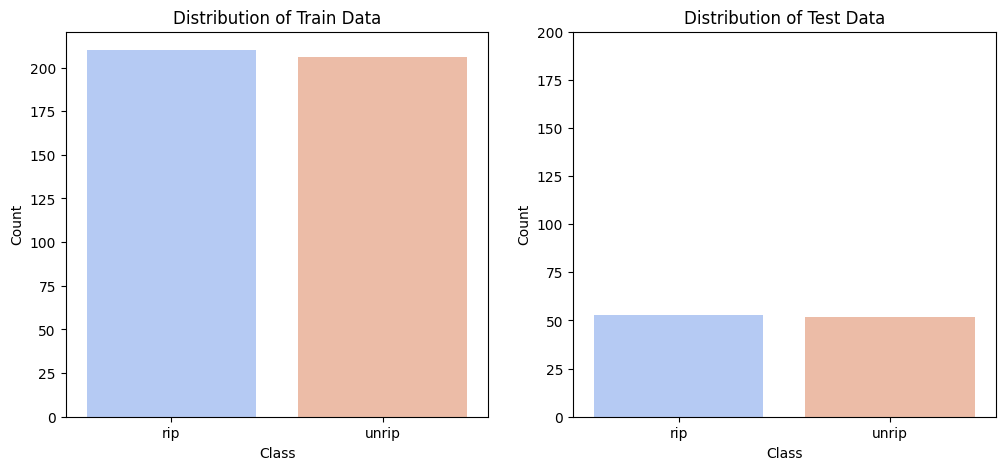

In [8]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터셋 경로
train_path = "./strawberryDataset/train/"
test_path = "./strawberryDataset/test/"

# 클래스별 이미지 개수 카운트
categories = ["rip", "unrip"]
data_counts = {
    "train": {category: len(os.listdir(os.path.join(train_path, category))) for category in categories},
    "test": {category: len(os.listdir(os.path.join(test_path, category))) for category in categories}
}

# 데이터 프레임 생성
df_train = pd.DataFrame(list(data_counts["train"].items()), columns=["Class", "Count"])
df_test = pd.DataFrame(list(data_counts["test"].items()), columns=["Class", "Count"])

# 시각화 (Train 데이터 분포)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x="Class", y="Count", data=df_train, palette="coolwarm")
plt.title("Distribution of Train Data")

# 시각화 (Test 데이터 분포)
plt.subplot(1, 2, 2)
sns.barplot(x="Class", y="Count", data=df_test, palette="coolwarm")
plt.ylim(0,200)
plt.title("Distribution of Test Data")

plt.show()


🍓 익은 딸기 샘플


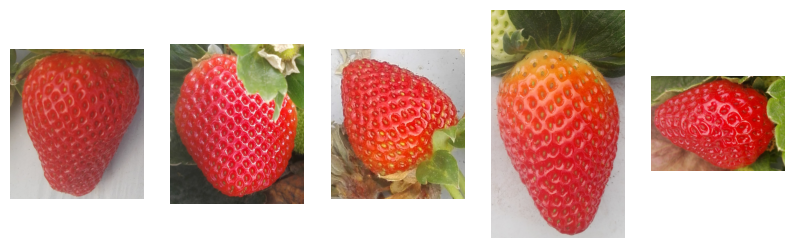

🍏 덜 익은 딸기 샘플


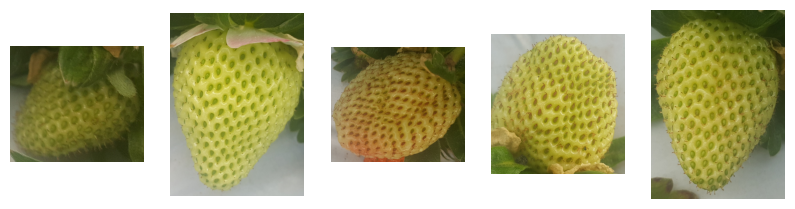

In [10]:
import cv2
import matplotlib.pyplot as plt
import random

# 샘플 이미지 표시 함수
def show_images(folder, category, num=5):
    path = os.path.join(folder, category)
    images = random.sample(os.listdir(path), min(num, len(os.listdir(path))))  # 파일 개수가 적으면 최대 개수만큼
    plt.figure(figsize=(10, 5))
    
    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR 순서라 변환 필요
        plt.subplot(1, num, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.show()

# "익은 딸기" 샘플 시각화
print("🍓 익은 딸기 샘플")
show_images(train_path, "rip")

# "덜 익은 딸기" 샘플 시각화
print("🍏 덜 익은 딸기 샘플")
show_images(train_path, "unrip")

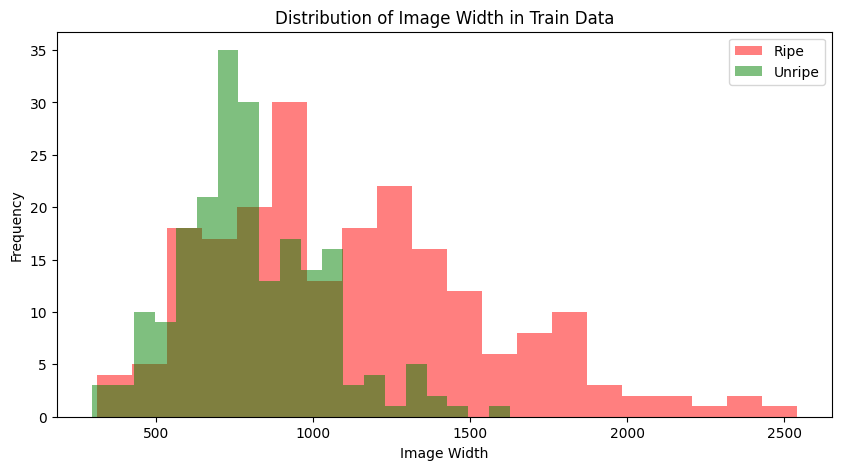

In [11]:
import numpy as np

# 이미지 크기 확인 함수
def get_image_sizes(folder, category):
    path = os.path.join(folder, category)
    sizes = []
    
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, _ = img.shape
            sizes.append((w, h))

    return np.array(sizes)

# Train 데이터 이미지 크기 저장
rip_sizes = get_image_sizes(train_path, "rip")
unrip_sizes = get_image_sizes(train_path, "unrip")

# 히스토그램 시각화
plt.figure(figsize=(10, 5))
plt.hist(rip_sizes[:, 0], bins=20, alpha=0.5, label="Ripe", color="red")
plt.hist(unrip_sizes[:, 0], bins=20, alpha=0.5, label="Unripe", color="green")
plt.legend()
plt.xlabel("Image Width")
plt.ylabel("Frequency")
plt.title("Distribution of Image Width in Train Data")
plt.show()

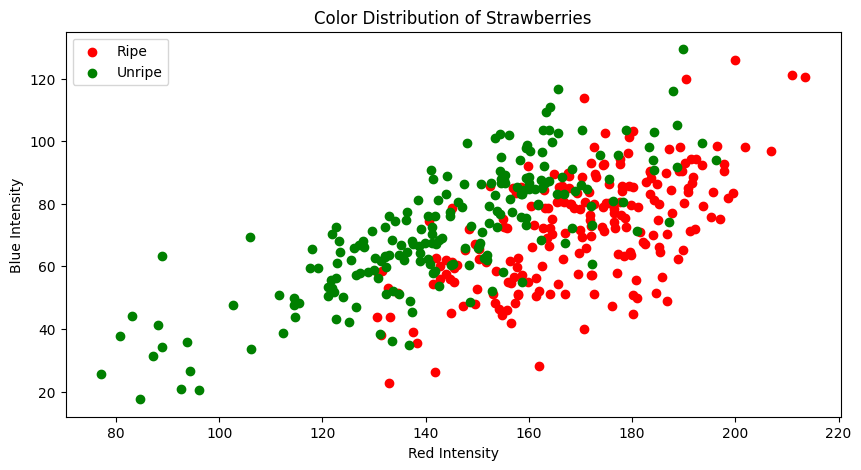

In [12]:
# RGB 평균값 분석
def get_avg_rgb(folder, category):
    path = os.path.join(folder, category)
    avg_colors = []

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            avg_color = np.mean(img, axis=(0, 1))  # 평균 RGB 값
            avg_colors.append(avg_color)

    return np.array(avg_colors)

rip_rgb = get_avg_rgb(train_path, "rip")
unrip_rgb = get_avg_rgb(train_path, "unrip")

# 산점도 시각화
plt.figure(figsize=(10, 5))
plt.scatter(rip_rgb[:, 2], rip_rgb[:, 0], color="red", label="Ripe")  # 빨간색 (익은 딸기)
plt.scatter(unrip_rgb[:, 2], unrip_rgb[:, 0], color="green", label="Unripe")  # 초록색 (덜 익은 딸기)
plt.xlabel("Red Intensity")
plt.ylabel("Blue Intensity")
plt.legend()
plt.title("Color Distribution of Strawberries")
plt.show()

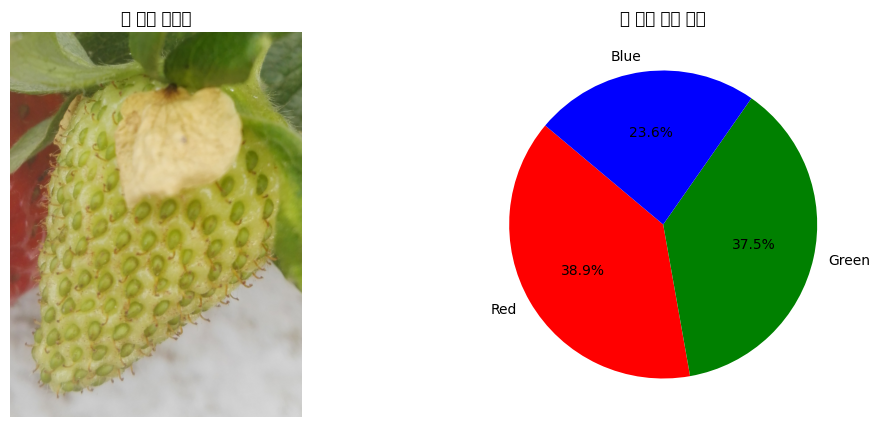

📊 평균 RGB 값: [164 158  99]
🔴 Red: 38.91% 🟢 Green: 37.50% 🔵 Blue: 23.60%


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "strawberryDataset/train/unrip/fresa_040.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2️⃣ 이미지의 평균 RGB 값 계산
avg_color_per_row = np.mean(image, axis=0)  # 각 행의 평균
avg_color = np.mean(avg_color_per_row, axis=0)  # 전체 평균

# 3️⃣ 색상 비율 계산 (정규화)
total = np.sum(avg_color)
color_ratios = (avg_color / total) * 100  # 색상 비율(퍼센트)
labels = ["Red", "Green", "Blue"]
colors = ["red", "green", "blue"]

# 4️⃣ 시각화 (원본 이미지 & 색 비율)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (1) 원본 이미지 표시
axes[0].imshow(image)
axes[0].set_title("📸 딸기 이미지")
axes[0].axis("off")

# (2) 색상 비율 원형 그래프
axes[1].pie(color_ratios, labels=labels, colors=colors, autopct="%1.1f%%", startangle=140)
axes[1].set_title("🎨 색상 비율 분석")

plt.show()

# 5️⃣ 분석 결과 출력
print(f"📊 평균 RGB 값: {avg_color.astype(int)}")
print(f"🔴 Red: {color_ratios[0]:.2f}% 🟢 Green: {color_ratios[1]:.2f}% 🔵 Blue: {color_ratios[2]:.2f}%")


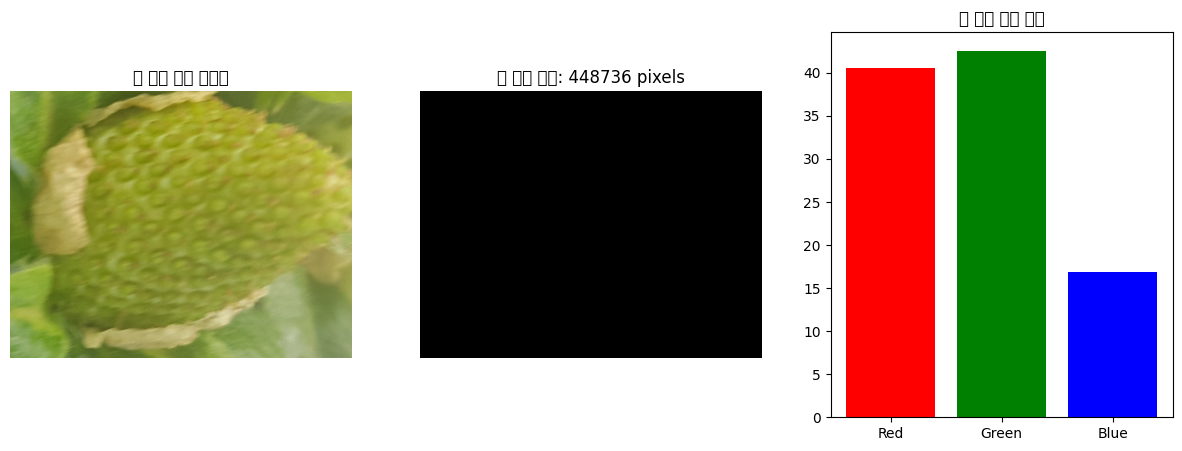

📊 평균 RGB 값: [145 152  60]
🔴 Red: 40.52% 🟢 Green: 42.57% 🔵 Blue: 16.91%
🍓 LAB 색상 평균: L=60.79, A=-15.29, B=45.68
🏷️ 딸기 면적: 448736 pixels
📌 예측된 숙성도: 🍓 익은 딸기 (Ripe)


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2lab

# 1️⃣ 이미지 불러오기 및 전처리
image_path = "strawberryDataset/train/unrip/fresa_500.jpg" # 딸기 이미지 경로
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV 기본 BGR → RGB 변환

# 2️⃣ 딸기 영역 분리 (배경 제거)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)  # 흑백 변환
_, mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)  # 이진화 (Thresholding)

# 3️⃣ 딸기 면적 계산
strawberry_area = np.sum(mask == 255)  # 흰색(255) 픽셀 개수

# 4️⃣ 색상 비율 추출 (RGB 평균)
avg_color_per_row = np.mean(image, axis=0)
avg_color = np.mean(avg_color_per_row, axis=0)  # 전체 평균

# 5️⃣ LAB 색 공간 변환 (더 정확한 색상 분석)
lab_image = rgb2lab(image)
L, A, B = np.mean(lab_image[:,:,0]), np.mean(lab_image[:,:,1]), np.mean(lab_image[:,:,2])

# 6️⃣ 색 비율 히스토그램 생성
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (1) 원본 이미지
axes[0].imshow(image)
axes[0].set_title("📸 원본 딸기 이미지")
axes[0].axis("off")

# (2) 딸기 영역 마스킹 결과
axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"🏷️ 딸기 면적: {strawberry_area} pixels")
axes[1].axis("off")

# (3) 색 비율 히스토그램
colors = ["red", "green", "blue"]
color_ratios = (avg_color / np.sum(avg_color)) * 100
axes[2].bar(["Red", "Green", "Blue"], color_ratios, color=colors)
axes[2].set_title("🎨 딸기 색상 비율")

plt.show()

# 7️⃣ 숙성도 예측 (가정: Red가 많을수록 익음)
if color_ratios[0] >= 40:  # Red 비율이 60% 이상이면 익음
    ripeness = "🍓 익은 딸기 (Ripe)"
elif 30 < color_ratios[0] <= 60:
    ripeness = "🍏 덜 익은 딸기 (Unripe)"
else:
    ripeness = "🟡 미숙한 딸기 (Not Ripe)"

# 8️⃣ 분석 결과 출력
print(f"📊 평균 RGB 값: {avg_color.astype(int)}")
print(f"🔴 Red: {color_ratios[0]:.2f}% 🟢 Green: {color_ratios[1]:.2f}% 🔵 Blue: {color_ratios[2]:.2f}%")
print(f"🍓 LAB 색상 평균: L={L:.2f}, A={A:.2f}, B={B:.2f}")
print(f"🏷️ 딸기 면적: {strawberry_area} pixels")
print(f"📌 예측된 숙성도: {ripeness}")


0: 640x544 1 orange, 38.0ms
Speed: 3.4ms preprocess, 38.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 544)


2025-02-21 14:25:01.697 Python[2176:4841734] +[IMKClient subclass]: chose IMKClient_Modern
2025-02-21 14:25:01.697 Python[2176:4841734] +[IMKInputSession subclass]: chose IMKInputSession_Modern


: 